# Human-in-the-Loop 

## STRATEGY: percentage-based uncertainty band

The `HUMAN_REVIEW_PCT%` of samples closest to the Youden-J decision boundary are flagged for human review.

## distance-to-threshold :

Reconstruction scores span 4+ orders of magnitude. Fixed bands need re-tuning after every FL round. **Distance-to-boundary** is self-calibrating: it always sends exactly `HUMAN_REVIEW_PCT%` to analysts regardless of score drift.

## Routing Rules

| Condition | Action |
|-----------|--------|
| `\|log_score - T_LOG\| > dist_cutoff` AND `score < T_YOUDEN` | 🟢 **AUTO-PASS** — certainly normal, skip analyst |
| `\|log_score - T_LOG\| ≤ dist_cutoff` | 🟡 **HUMAN REVIEW** — ambiguous, analyst decides |
| `\|log_score - T_LOG\| > dist_cutoff` AND `score ≥ T_YOUDEN` | 🔴 **AUTO-ALERT** — certainly attack, raise alarm |

## Confidence Function (sigmoid, log-space)
conf = sigmoid(K * (log_score - T_LOG))


| Value | Interpretation |
|-------|----------------|
| 0.0 | certainly normal |
| 0.5 | maximally ambiguous |
| 1.0 | certainly attack |

## Key Parameters

- **`HUMAN_REVIEW_PCT`** : percentage of samples to be reviewed by analysts
- **`dist_cutoff`** : distance threshold (defined by the `HUMAN_REVIEW_PCT` percentile of distances to `T_LOG`)
- **`T_LOG`** : optimal threshold (Youden-J) in log scale
- **`T_YOUDEN`** : optimal threshold in original scale
- **`K`** : slope factor for the sigmoid

define paths and prams

In [ ]:
import os
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path

import numpy  as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn

# ── Paths (adapter si nécessaire) ───────────────────────────────
MODEL_PATH  = "./models/federated/fl_global_model.pt"
SCALER_PATH = "./models/federated/fl_scaler.pkl"
DATA_PATH   = "./data/dataset_test_complet.csv"
OUTPUT_DIR  = Path("./output")

# ── Human-in-the-loop params ─────────────────────────────────────
K          = 2.0    # pente de la sigmoïde (sensibilité)
LOW_CONF   = 0.30   # en-dessous → auto-pass
HIGH_CONF  = 0.70   # au-dessus  → auto-alert

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'HITL params : k={K}  low={LOW_CONF}  high={HIGH_CONF}')


Device : cpu
HITL params : k=2.0  low=0.3  high=0.7


Autoencoder Architecture

In [3]:
class DropoutAutoencoder(nn.Module):
    """Symmetric Autoencoder 11→32→16→6→16→32→11"""
    def __init__(self, input_dim=11, hidden=32, latent=6, p=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(), nn.Dropout(p),
            nn.Linear(hidden, 16),        nn.Tanh(), nn.Dropout(p),
            nn.Linear(16, latent),        nn.Tanh(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 16),        nn.Tanh(), nn.Dropout(p),
            nn.Linear(16, hidden),        nn.Tanh(), nn.Dropout(p),
            nn.Linear(hidden, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


FEATURES = [
    'ratio_max_mean_pkts_norm', 'pkts_total_p99_norm',    'bytes_total_p99_norm',
    'proto_udp_share_norm',     'proto_icmp_share_norm',  'syn_ratio_norm',
    'entropy_ip_src_norm',      'pkt_arrivals_avg_p1_norm','pkt_size_avg_p1_norm',
    'heure_sin_norm',           'heure_cos_norm'
]

@torch.no_grad()
def compute_scores(model, X_np):
    model.eval()
    T = torch.FloatTensor(X_np).to(DEVICE)
    return ((T - model(T)) ** 2).mean(dim=1).cpu().numpy()

print('Architecture définie ✓')


Architecture définie ✓


Load model, scaler, and test data 

In [ ]:

# Load scaler
scaler = joblib.load(SCALER_PATH)
print(f'Scaler loaded ✓  ({type(scaler).__name__})')

# Load model
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE,weights_only =False)
arch = checkpoint.get('architecture', {'input_dim': 11, 'hidden': 32, 'latent': 6, 'p': 0.2})
model = DropoutAutoencoder(**arch).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Model loaded ✓   (best_round={checkpoint["fl_config"]["best_round"]})')

# Recover Youden-J threshold from saved model (computed on val_labeled during FL)
T_YOUDEN = checkpoint['thresholds']['youden_j']
print(f'Threshold T_YOUDEN = {T_YOUDEN:.6f}  (Youden-J from FL training)')

# Load the full test CSV
df_test = pd.read_csv(DATA_PATH)
X_raw   = df_test[FEATURES].values
y_true  = df_test['target'].values if 'target' in df_test.columns else None
print(f'\nTest data loaded : {len(df_test):,} rows')
if y_true is not None:
    print(f'  Attack rate     : {y_true.mean():.1%}')


Compute anomaly reconstruction scores

Log-transform for stable confidence calibration Raw reconstruction scores span 4+ orders of magnitude.
Working in log-space makes the distance-to-threshold metric robust to the extreme right tail of attack scores.

In [ ]:

X_scaled = scaler.transform(X_raw)
scores   = compute_scores(model, X_scaled)

print(f'Scores computed on {len(scores):,} samples ✓')
print(f'  min  : {scores.min():.4f}')
print(f'  mean : {scores.mean():.4f}')
print(f'  p99  : {np.percentile(scores, 99):.4f}')
print(f'  max  : {scores.max():.4f}')
print(f'  T_YOUDEN : {T_YOUDEN:.4f}')


scores_log = np.log1p(scores)
T_LOG      = np.log1p(T_YOUDEN)
print(f'\nLog-space T_LOG  : {T_LOG:.4f}')


Scores computed on 22,280 samples ✓
  min  : 0.0255
  mean : 786027.4375
  p99  : 24113592.0000
  max  : 24515042.0000
  T_YOUDEN : 11.3101

Log-space T_LOG  : 2.5104


Configuration & Routing

In [ ]:


HUMAN_REVIEW_PCT = 0.10   # fraction of samples sent to analysts (10%)
K_SIGMOID        = 3.0    # sigmoid steepness; higher = harder boundary

# Distance of each sample to the decision boundary (log-space)
dist        = np.abs(scores_log - T_LOG)
dist_cutoff = np.percentile(dist, HUMAN_REVIEW_PCT * 100)

# ── Routing masks ──────────────────────────────────────────────────
human_zone = dist <= dist_cutoff
auto_pass  = (~human_zone) & (scores < T_YOUDEN)
auto_alert = (~human_zone) & (scores >= T_YOUDEN)

# ── Confidence score [0, 1] ────────────────────────────────────────
conf = 1 / (1 + np.exp(-K_SIGMOID * (scores_log - T_LOG)))

n = len(scores)
print('=' * 62)
print('HUMAN-IN-THE-LOOP ROUTING')
print('=' * 62)
print(f'  Strategy      : distance-to-boundary (log-space)')
print(f'  Review budget : {HUMAN_REVIEW_PCT:.0%}  ({human_zone.sum():,} samples)')
print(f'  Dist cutoff   : {dist_cutoff:.6f}')
print(f'  Sigmoid K     : {K_SIGMOID}')
print()
print(f'  🟢 Auto-pass    : {auto_pass.sum():>7,}  ({auto_pass.sum()/n:.1%})')
print(f'  🟡 Human Review : {human_zone.sum():>7,}  ({human_zone.sum()/n:.1%})')
print(f'  🔴 Auto-alert   : {auto_alert.sum():>7,}  ({auto_alert.sum()/n:.1%})')
print('=' * 62)
print()
print('Confidence stats per zone:')
for label, mask in [('Auto-pass', auto_pass), ('Human zone', human_zone), ('Auto-alert', auto_alert)]:
    if mask.sum() > 0:
        c = conf[mask]
        print(f'  {label:<12}  mean={c.mean():.3f}  std={c.std():.3f}  '
              f'[{c.min():.3f}, {c.max():.3f}]')


HUMAN-IN-THE-LOOP ROUTING
  Strategy      : distance-to-boundary (log-space)
  Review budget : 10%  (2,228 samples)
  Dist cutoff   : 2.152933
  Sigmoid K     : 3.0

  🟢 Auto-pass    :  15,052  (67.6%)
  🟡 Human Review :   2,228  (10.0%)
  🔴 Auto-alert   :   5,000  (22.4%)

Confidence stats per zone:
  Auto-pass     mean=0.001  std=0.000  [0.001, 0.002]
  Human zone    mean=0.004  std=0.013  [0.002, 0.363]
  Auto-alert    mean=1.000  std=0.000  [1.000, 1.000]


HITL Quality Metrics (requires ground-truth labels) 

In [ ]:


if y_true is None:
    print('No ground-truth labels — skipping quality metrics.')
else:
    from sklearn.metrics import precision_score, recall_score, f1_score

    print('=' * 62)
    print('HITL QUALITY METRICS')
    print('=' * 62)

    total_attacks = int(y_true.sum())

    # ── Zone composition ────────────────────────────────────────────
    print('\nZone composition (ground truth):')
    for label, mask in [('Auto-pass', auto_pass), ('Human zone', human_zone), ('Auto-alert', auto_alert)]:
        n_zone    = mask.sum()
        n_attacks = int(y_true[mask].sum())
        n_normal  = n_zone - n_attacks
        atk_rate  = n_attacks / n_zone if n_zone > 0 else 0
        print(f'  {label:<14}: {n_zone:>6,} total | '
              f'normal={n_normal:,}  attacks={n_attacks:,}  attack_rate={atk_rate:.1%}')

    # ── Auto-only performance ───────────────────────────────────────
    auto_mask = auto_pass | auto_alert
    pred_auto = (scores[auto_mask] >= T_YOUDEN).astype(int)
    y_auto    = y_true[auto_mask]

    print(f'\nAuto-only performance (excluding {HUMAN_REVIEW_PCT:.0%} review zone):')
    print(f'  Coverage  : {auto_mask.sum()/n:.1%}  ({auto_mask.sum():,} samples)')
    if len(np.unique(y_auto)) > 1:
        print(f'  Precision : {precision_score(y_auto, pred_auto):.4f}')
        print(f'  Recall    : {recall_score(y_auto, pred_auto):.4f}')
        print(f'  F1        : {f1_score(y_auto, pred_auto):.4f}')

    # ── What the human review zone contains ────────────────────────
    atk_in_review = int(y_true[human_zone].sum())
    print(f'\nHuman-review zone ({human_zone.sum():,} samples):')
    print(f'  {atk_in_review:,} attacks  ({atk_in_review/total_attacks:.1%} of all attacks)')
    print(f'  {int((~y_true[human_zone].astype(bool)).sum()):,} normal samples')

    # ── Error reduction compared to no-HITL ─────────────────────────
    pred_nohitl = (scores >= T_YOUDEN).astype(int)
    fp_nohitl = int(((pred_nohitl==1) & (y_true==0)).sum())
    fn_nohitl = int(((pred_nohitl==0) & (y_true==1)).sum())
    fp_auto   = int((auto_alert & (y_true==0)).sum())
    fn_auto   = int((auto_pass  & (y_true==1)).sum())

    print(f'\nError reduction from HITL:')
    print(f'  False Positives — No HITL: {fp_nohitl:,}  →  Auto-alert only: {fp_auto:,}  '
          f'(−{fp_nohitl - fp_auto:,})')
    print(f'  False Negatives — No HITL: {fn_nohitl:,}  →  Auto-pass  only: {fn_auto:,}  '
          f'(−{fn_nohitl - fn_auto:,})')
    print(f'  Human review absorbs {atk_in_review:,} attacks for analyst verification.')
    print('=' * 62)


HITL QUALITY METRICS

Zone composition (ground truth):
  Auto-pass     : 15,052 total | normal=15,052  attacks=0  attack_rate=0.0%
  Human zone    :  2,228 total | normal=2,228  attacks=0  attack_rate=0.0%
  Auto-alert    :  5,000 total | normal=0  attacks=5,000  attack_rate=100.0%

Auto-only performance (excluding 10% review zone):
  Coverage  : 90.0%  (20,052 samples)
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000

Human-review zone (2,228 samples):
  0 attacks  (0.0% of all attacks)
  2,228 normal samples

Error reduction from HITL:
  False Positives — No HITL: 0  →  Auto-alert only: 0  (−0)
  False Negatives — No HITL: 0  →  Auto-pass  only: 0  (−0)
  Human review absorbs 0 attacks for analyst verification.


Build per-sample HITL dataframe + analyst queue

In [ ]:


# Route labels
route_labels = np.where(auto_pass, 'AUTO-PASS',
               np.where(human_zone, 'HUMAN-REVIEW', 'AUTO-ALERT'))

# Urgency tier within human-review zone (based on confidence)
urgency = np.full(n, 'N/A', dtype=object)
if human_zone.sum() > 0:
    conf_in_zone = conf[human_zone]
    ranks        = conf_in_zone.argsort().argsort()
    pct_rank     = ranks / max(human_zone.sum() - 1, 1)
    tier         = np.where(pct_rank >= 0.67, 'HIGH',
                   np.where(pct_rank >= 0.34, 'MEDIUM', 'LOW'))
    urgency[human_zone] = tier
df_hitl = df_test.copy()
df_hitl['recon_score']   = scores
df_hitl['log_score']     = scores_log
df_hitl['confidence']    = conf
df_hitl['dist_boundary'] = dist
df_hitl['route']         = route_labels
df_hitl['urgency']       = urgency

# Analyst queue: human-review samples sorted by proximity to boundary
# (most uncertain = smallest dist = highest priority for analyst)
df_analyst_queue = (
    df_hitl[df_hitl['route'] == 'HUMAN-REVIEW']
    .sort_values('dist_boundary')
    .reset_index(drop=True)
)

print(f'HITL dataframe ready : {len(df_hitl):,} rows')
print(f'Analyst queue        : {len(df_analyst_queue):,} samples (sorted by uncertainty)')
print()

cols_show = ['recon_score', 'log_score', 'confidence', 'dist_boundary', 'urgency']
if y_true is not None:
    # Align true labels with the human-review subset
    df_analyst_queue['true_label'] = y_true[df_hitl['route'].values == 'HUMAN-REVIEW']
    cols_show.append('true_label')

print('Top-10 most uncertain samples (closest to decision boundary):')
print(df_analyst_queue[cols_show].head(10).to_string())

# Export
df_hitl.to_csv(OUTPUT_DIR / 'hitl_routing_full.csv', index=False)
df_analyst_queue.to_csv(OUTPUT_DIR / 'hitl_analyst_queue.csv', index=False)
print(f'\nExported → {OUTPUT_DIR}/hitl_routing_full.csv')
print(f'Exported → {OUTPUT_DIR}/hitl_analyst_queue.csv')


HITL dataframe ready : 22,280 rows
Analyst queue        : 2,228 samples (sorted by uncertainty)

Top-10 most uncertain samples (closest to decision boundary):
   recon_score  log_score  confidence  dist_boundary urgency  true_label
0     9.211776   2.323542    0.363401       0.186878    HIGH           0
1     6.679213   2.038517    0.195335       0.471902    HIGH           0
2     6.292340   1.986825    0.172105       0.523595    HIGH           0
3     6.246177   1.980474    0.169407       0.529945    HIGH           0
4     5.812109   1.918702    0.144903       0.591718    HIGH           0
5     5.441696   1.862792    0.125331       0.647628    HIGH           0
6     5.092497   1.807058    0.108121       0.703362    HIGH           0
7     5.047960   1.799721    0.106016       0.710698    HIGH           0
8     5.015265   1.794300    0.104485       0.716119    HIGH           0
9     4.844999   1.765586    0.096695       0.744833    HIGH           0

Exported → /kaggle/working/FedGuard/h

Human-in-the-Loop Visualizations 

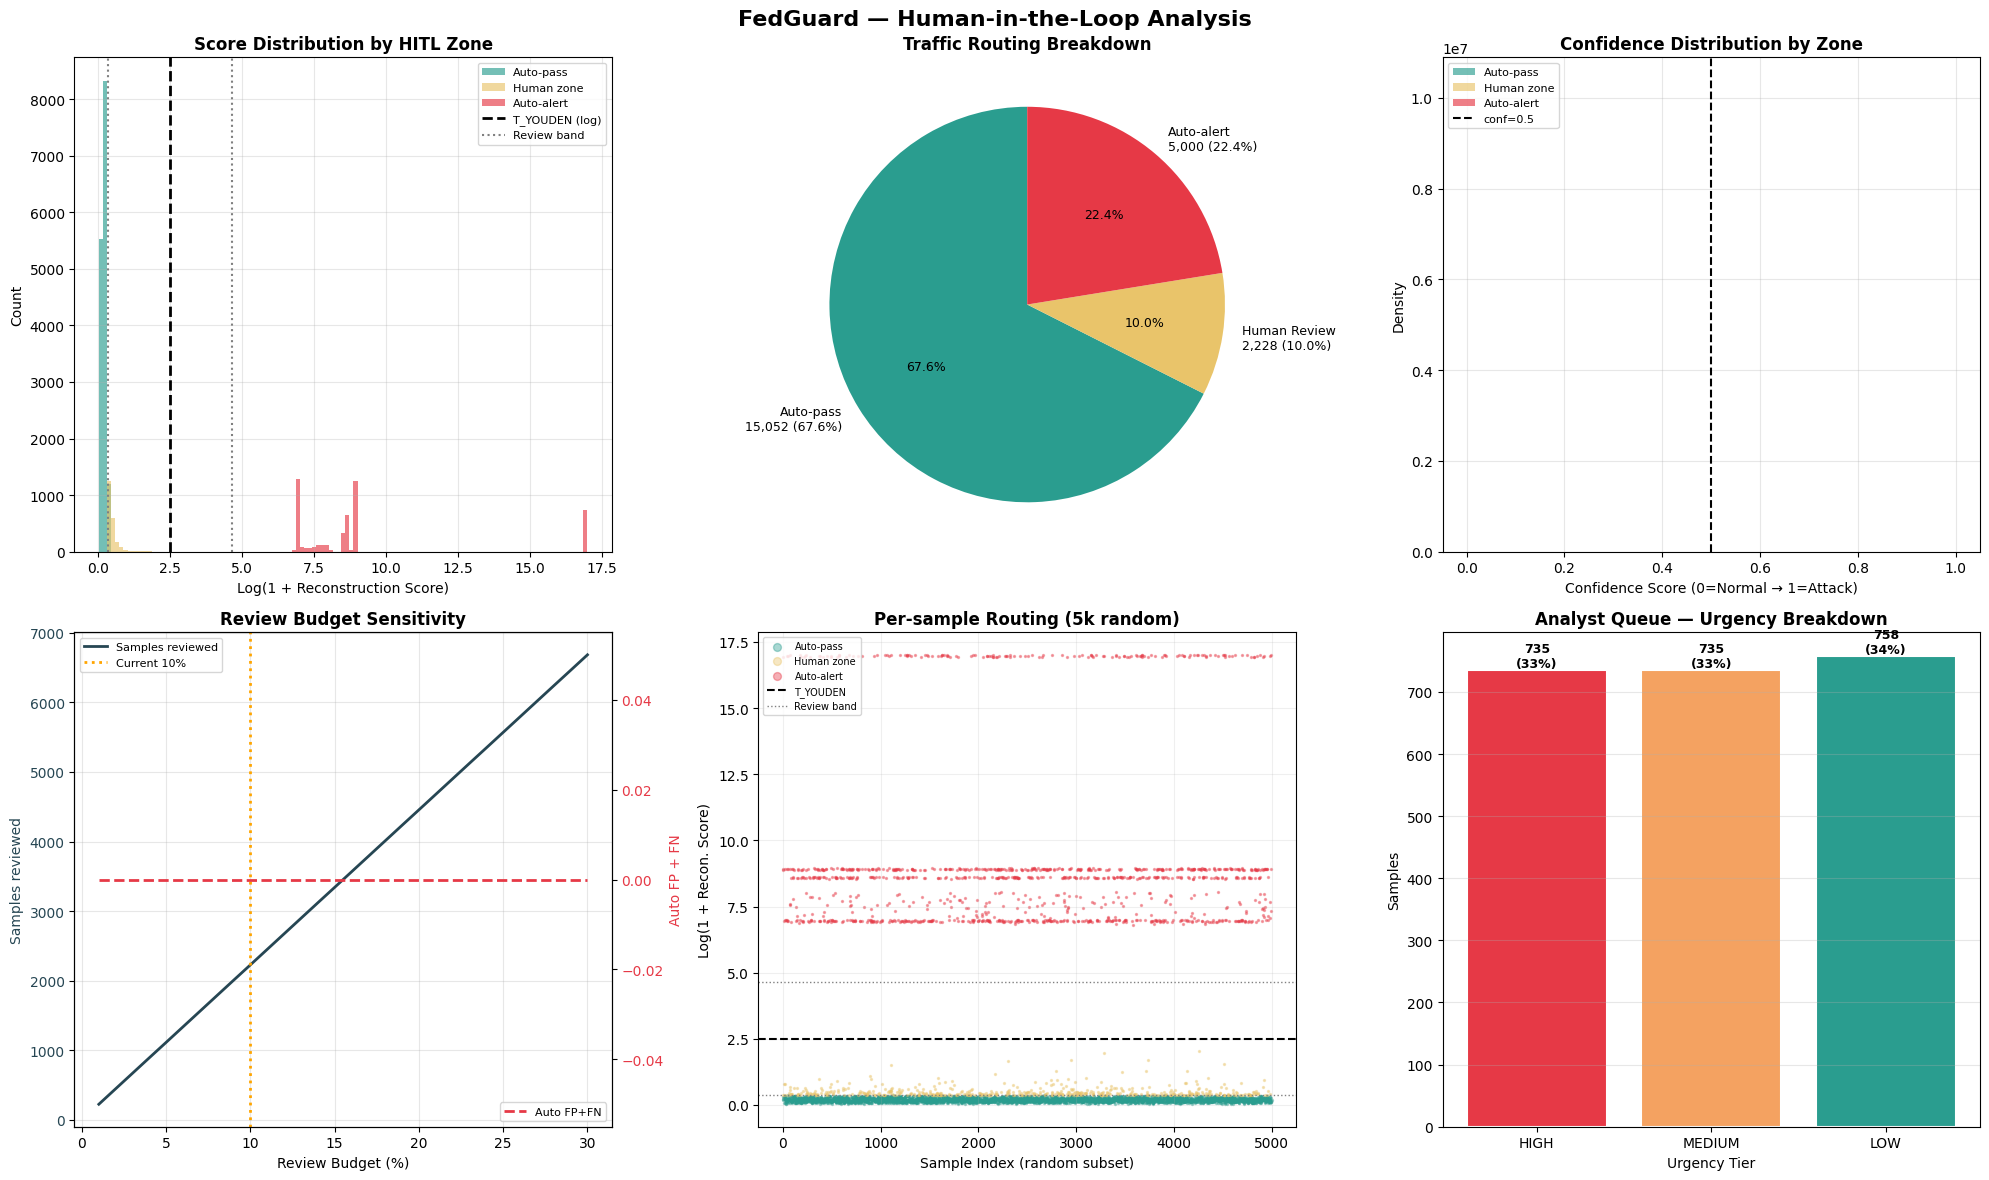

Saved: /kaggle/working/FedGuard/hitl_analysis.png


In [ ]:


COLORS = {
    'Auto-pass'   : '#2A9D8F',
    'Human zone'  : '#E9C46A',
    'Auto-alert'  : '#E63946',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('FedGuard — Human-in-the-Loop Analysis', fontsize=16, fontweight='bold')

# ── 1. Score distribution with routing zones ──────────────────────
ax = axes[0, 0]
plot_max = np.percentile(scores_log, 99.5)
bins = np.linspace(scores_log.min(), plot_max, 120)
for label, mask in [('Auto-pass', auto_pass), ('Human zone', human_zone), ('Auto-alert', auto_alert)]:
    ax.hist(np.clip(scores_log[mask], None, plot_max),
            bins=bins, alpha=0.65, color=COLORS[label], label=label)
ax.axvline(T_LOG, color='black', lw=2, linestyle='--', label='T_YOUDEN (log)')
ax.axvline(T_LOG - dist_cutoff, color='grey', lw=1.5, linestyle=':', label='Review band')
ax.axvline(T_LOG + dist_cutoff, color='grey', lw=1.5, linestyle=':')
ax.set_xlabel('Log(1 + Reconstruction Score)')
ax.set_ylabel('Count')
ax.set_title('Score Distribution by HITL Zone', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. Routing pie chart ──────────────────────────────────────────
ax = axes[0, 1]
counts   = [auto_pass.sum(), human_zone.sum(), auto_alert.sum()]
pie_lbls = [
    f'Auto-pass\n{auto_pass.sum():,} ({auto_pass.sum()/n:.1%})',
    f'Human Review\n{human_zone.sum():,} ({human_zone.sum()/n:.1%})',
    f'Auto-alert\n{auto_alert.sum():,} ({auto_alert.sum()/n:.1%})',
]
ax.pie(counts, labels=pie_lbls,
       colors=[COLORS['Auto-pass'], COLORS['Human zone'], COLORS['Auto-alert']],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax.set_title('Traffic Routing Breakdown', fontweight='bold')

# ── 3. Confidence distribution ────────────────────────────────────
ax = axes[0, 2]
for label, mask in [('Auto-pass', auto_pass), ('Human zone', human_zone), ('Auto-alert', auto_alert)]:
    ax.hist(conf[mask], bins=50, alpha=0.65, color=COLORS[label], label=label, density=True)
ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='conf=0.5')
ax.set_xlabel('Confidence Score (0=Normal → 1=Attack)')
ax.set_ylabel('Density')
ax.set_title('Confidence Distribution by Zone', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. Review budget sensitivity curve ───────────────────────────
ax = axes[1, 0]
budgets    = np.arange(0.01, 0.31, 0.01)
n_reviewed = []
n_auto_err = []
for pct in budgets:
    dc = np.percentile(dist, pct * 100)
    hz = dist <= dc
    ap = (~hz) & (scores < T_YOUDEN)
    aa = (~hz) & (scores >= T_YOUDEN)
    n_reviewed.append(hz.sum())
    if y_true is not None:
        fn_a = (ap & y_true.astype(bool)).sum()
        fp_a = (aa & ~y_true.astype(bool)).sum()
        n_auto_err.append(fn_a + fp_a)
    else:
        n_auto_err.append(np.nan)
ax2b = ax.twinx()
ax.plot(budgets * 100, n_reviewed, color='#264653', lw=2, label='Samples reviewed')
ax.axvline(HUMAN_REVIEW_PCT * 100, color='orange', lw=2, linestyle=':', label=f'Current {HUMAN_REVIEW_PCT:.0%}')
ax.set_xlabel('Review Budget (%)'); ax.set_ylabel('Samples reviewed', color='#264653')
ax.tick_params(axis='y', labelcolor='#264653')
if y_true is not None:
    ax2b.plot(budgets * 100, n_auto_err, color='#E63946', lw=2, linestyle='--', label='Auto FP+FN')
    ax2b.set_ylabel('Auto FP + FN', color='#E63946')
    ax2b.tick_params(axis='y', labelcolor='#E63946')
    ax2b.legend(loc='lower right', fontsize=8)
ax.set_title('Review Budget Sensitivity', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=8)

# ── 5. Per-sample scatter (random 5k) ────────────────────────────
ax = axes[1, 1]
np.random.seed(42)
sidx = np.random.choice(n, size=min(5000, n), replace=False)
for label, mask in [('Auto-pass', auto_pass), ('Human zone', human_zone), ('Auto-alert', auto_alert)]:
    sm = mask[sidx]
    ax.scatter(np.where(sm)[0], scores_log[sidx][sm], s=2, alpha=0.4,
               color=COLORS[label], label=label)
ax.axhline(T_LOG, color='black', lw=1.5, linestyle='--', label='T_YOUDEN')
ax.axhline(T_LOG - dist_cutoff, color='grey', lw=1, linestyle=':')
ax.axhline(T_LOG + dist_cutoff, color='grey', lw=1, linestyle=':', label='Review band')
ax.set_xlabel('Sample Index (random subset)'); ax.set_ylabel('Log(1 + Recon. Score)')
ax.set_title('Per-sample Routing (5k random)', fontweight='bold')
ax.legend(fontsize=7, markerscale=4); ax.grid(alpha=0.2)

# ── 6. Urgency breakdown within human zone ───────────────────────
ax = axes[1, 2]
urg_vals  = urgency[human_zone]
urg_order = ['HIGH', 'MEDIUM', 'LOW']
urg_count = [np.sum(urg_vals == u) for u in urg_order]
urg_clrs  = ['#E63946', '#F4A261', '#2A9D8F']
bars = ax.bar(urg_order, urg_count, color=urg_clrs, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, urg_count):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{cnt:,}\n({cnt/max(human_zone.sum(),1):.0%})',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Urgency Tier'); ax.set_ylabel('Samples')
ax.set_title('Analyst Queue — Urgency Breakdown', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hitl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', OUTPUT_DIR / 'hitl_analysis.png')


Confusion matrices — Full vs Auto-only vs Ideal HITL

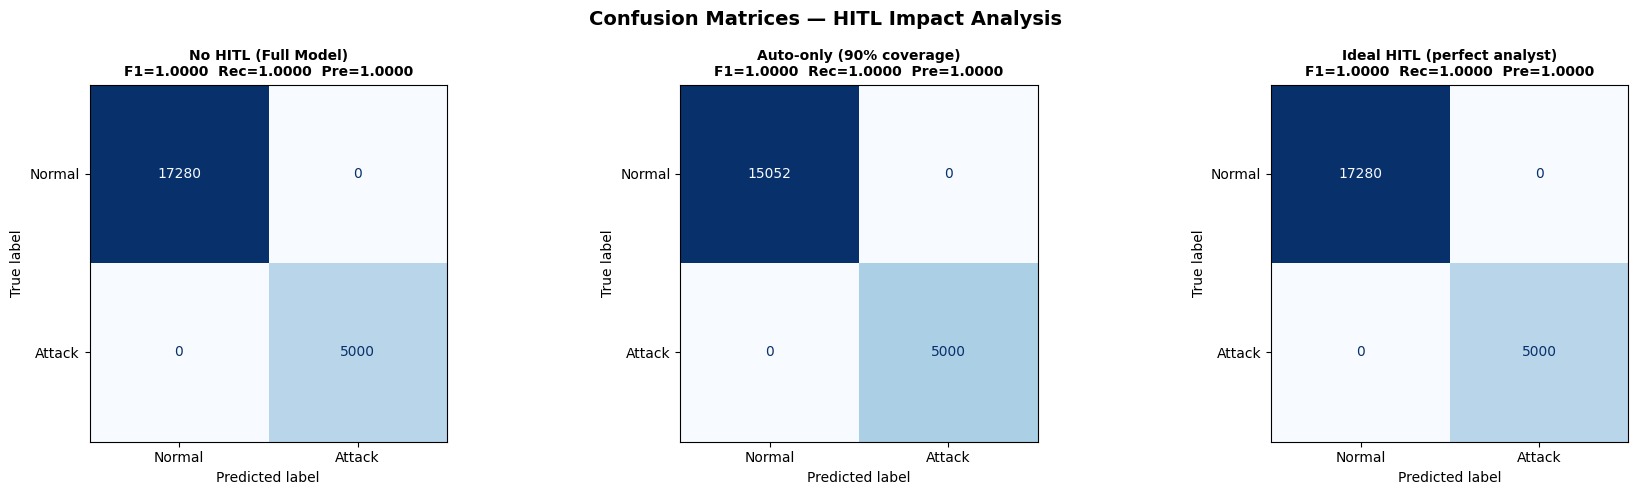

Saved: /kaggle/working/FedGuard/hitl_confusion_matrices.png


In [ ]:


if y_true is None:
    print('Ground-truth labels required for confusion matrices.')
else:
    from sklearn.metrics import (
        confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score
    )

    # 1. Full model — no HITL, Youden-J threshold
    pred_full  = (scores >= T_YOUDEN).astype(int)

    # 2. Auto-only — exclude the human-review zone entirely
    auto_sel   = auto_pass | auto_alert
    pred_auto  = pred_full[auto_sel]
    y_auto     = y_true[auto_sel]

    # 3. Ideal HITL — assume a perfect analyst correctly labels all
    #    human-review samples (upper bound on HITL benefit)
    pred_ideal = pred_full.copy()
    pred_ideal[human_zone] = y_true[human_zone]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Confusion Matrices — HITL Impact Analysis',
                 fontweight='bold', fontsize=14)

    configs = [
        (y_true,  pred_full,  'No HITL (Full Model)'),
        (y_auto,  pred_auto,  f'Auto-only ({auto_sel.sum()/n:.0%} coverage)'),
        (y_true,  pred_ideal, 'Ideal HITL (perfect analyst)'),
    ]

    for ax, (yt, yp, title) in zip(axes, configs):
        cm = confusion_matrix(yt, yp)
        ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']
                               ).plot(ax=ax, colorbar=False, cmap='Blues')
        f1  = f1_score(yt, yp)
        rec = recall_score(yt, yp)
        pre = precision_score(yt, yp)
        ax.set_title(f'{title}\nF1={f1:.4f}  Rec={rec:.4f}  Pre={pre:.4f}',
                     fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'hitl_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', OUTPUT_DIR / 'hitl_confusion_matrices.png')


Final Summary 

In [ ]:

print('=' * 65)
print('FEDGUARD — HUMAN-IN-THE-LOOP FINAL SUMMARY')
print('=' * 65)
print()
print(f'  Model          : FedAvg DropoutAutoencoder (11→32→16→6→16→32→11)')
print(f'  Threshold      : T_YOUDEN = {T_YOUDEN:.6f}  (Youden-J from FL)')
print(f'  Strategy       : distance-to-boundary in log-space')
print(f'  Review budget  : {HUMAN_REVIEW_PCT:.0%}  |  Sigmoid K={K_SIGMOID}')
print()
print(f'  Total samples  : {n:,}')
print(f'  🟢 Auto-pass   : {auto_pass.sum():>7,}  ({auto_pass.sum()/n:.1%})')
print(f'  🟡 Human Review: {human_zone.sum():>7,}  ({human_zone.sum()/n:.1%})')
print(f'  🔴 Auto-alert  : {auto_alert.sum():>7,}  ({auto_alert.sum()/n:.1%})')

if y_true is not None:
    print()
    print('  Attacks per zone:')
    total_attacks = int(y_true.sum())
    for label, mask in [('Auto-pass', auto_pass), ('Human zone', human_zone), ('Auto-alert', auto_alert)]:
        atk = int(y_true[mask].sum())
        print(f'    {label:<14}: {atk:,}  ({atk/total_attacks:.1%} of all attacks)')

print()
print('  Urgency breakdown (human queue):')
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    cnt = int(np.sum(urgency[human_zone] == tier))
    print(f'    {tier:<8}: {cnt:,}  ({cnt/max(human_zone.sum(),1):.0%})')

print()
print('  Exports:')
print(f'    {OUTPUT_DIR}/hitl_routing_full.csv      ← all samples with route + confidence')
print(f'    {OUTPUT_DIR}/hitl_analyst_queue.csv     ← review queue sorted by uncertainty')
print(f'    {OUTPUT_DIR}/hitl_analysis.png          ← 6-panel analysis dashboard')
print(f'    {OUTPUT_DIR}/hitl_confusion_matrices.png← impact analysis (3 scenarios)')
print('=' * 65)


FEDGUARD — HUMAN-IN-THE-LOOP FINAL SUMMARY

  Model          : FedAvg DropoutAutoencoder (11→32→16→6→16→32→11)
  Threshold      : T_YOUDEN = 11.310093  (Youden-J from FL)
  Strategy       : distance-to-boundary in log-space
  Review budget  : 10%  |  Sigmoid K=3.0

  Total samples  : 22,280
  🟢 Auto-pass   :  15,052  (67.6%)
  🟡 Human Review:   2,228  (10.0%)
  🔴 Auto-alert  :   5,000  (22.4%)

  Attacks per zone:
    Auto-pass     : 0  (0.0% of all attacks)
    Human zone    : 0  (0.0% of all attacks)
    Auto-alert    : 5,000  (100.0% of all attacks)

  Urgency breakdown (human queue):
    HIGH    : 735  (33%)
    MEDIUM  : 735  (33%)
    LOW     : 758  (34%)

  Exports:
    /kaggle/working/FedGuard/hitl_routing_full.csv      ← all samples with route + confidence
    /kaggle/working/FedGuard/hitl_analyst_queue.csv     ← review queue sorted by uncertainty
    /kaggle/working/FedGuard/hitl_analysis.png          ← 6-panel analysis dashboard
    /kaggle/working/FedGuard/hitl_confusion_ma